# Food Ordering Behavior — ML Analysis

**Who is this for?**  
A college student who knows basic Python and wants to understand real Machine Learning workflows — not just copy-paste code, but actually understand what is happening and why.

**What this notebook covers:**
- Dataset generation and Exploratory Data Analysis (EDA)
- Feature engineering and encoding
- Scaling strategies and when to use them
- Four prediction tasks, each solved by four models:
  - Linear Regression
  - Decision Tree
  - Random Forest
  - K-Means Clustering (bonus: unsupervised)
- Head-to-head model comparisons with plots
- A final summary of best results

**How to use this:**  
Run cells top to bottom. Every code cell has comments. Every section has a plain-English explanation of what is happening before the code starts.

---
**Prediction Tasks:**

| Task | Type | Target |
|------|------|--------|
| Cuisine Prediction | Multi-class classification | Which cuisine was ordered |
| Repeat Order | Binary classification | Will the customer come back |
| Rating Prediction | Multi-class classification | Rating given (1 to 5) |
| Restaurant Type | Multi-class classification | Budget / Mid-range / Premium |
| Customer Segments | Unsupervised clustering | Natural customer groups |

## Section 1 — Generate the Dataset

We generate 50,000 food orders with realistic behavior built in. For example:
- People who are celebrating tend to choose premium restaurants
- Faster delivery leads to higher ratings
- Rating influences whether someone orders again

This makes the dataset learnable — patterns exist that our models can actually find.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N = 50000

cities        = ['Delhi', 'Mumbai', 'Bangalore', 'Hyderabad', 'Pune', 'Chandigarh']
cuisines      = ['Biryani', 'Chinese', 'Desserts', 'Fast Food', 'North Indian', 'South Indian']
meal_types    = ['Breakfast', 'Lunch', 'Dinner', 'Snacks']
rest_types    = ['Budget', 'Mid-range', 'Premium']
day_types     = ['Weekday', 'Weekend']
order_times   = ['Morning', 'Afternoon', 'Evening', 'Night']
moods         = ['Happy', 'Lazy', 'Celebrating', 'Stressed']
hunger_levels = ['Low', 'Medium', 'High']
companies     = ['Alone', 'Partner', 'Friends', 'Family']

mood_arr    = np.random.choice(moods, N)
company_arr = np.random.choice(companies, N, p=[0.30, 0.20, 0.25, 0.25])
hunger_arr  = np.random.choice(hunger_levels, N, p=[0.25, 0.45, 0.30])
day_arr     = np.random.choice(day_types, N, p=[0.55, 0.45])
time_arr    = np.random.choice(order_times, N)
city_arr    = np.random.choice(cities, N)
meal_arr    = np.random.choice(meal_types, N)
cuisine_arr = np.random.choice(cuisines, N)

# Restaurant type driven by mood and company
rest_arr = []
for comp, mood in zip(company_arr, mood_arr):
    if comp in ['Family', 'Friends'] or mood == 'Celebrating':
        rest_arr.append(np.random.choice(['Mid-range', 'Premium'], p=[0.5, 0.5]))
    else:
        rest_arr.append(np.random.choice(rest_types, p=[0.4, 0.35, 0.25]))
rest_arr = np.array(rest_arr)

base_spend = {'Budget': 200, 'Mid-range': 500, 'Premium': 800}
order_vals = np.array([int(np.clip(np.random.normal(base_spend[r], 150), 100, 999)) for r in rest_arr])
del_fees   = np.array([int(np.clip(np.random.normal(55, 20), 20, 99)) for _ in range(N)])
ages       = np.random.randint(18, 45, N)
time_order = np.random.randint(1, 15, N)
discount   = np.random.choice(['Yes', 'No'], N, p=[0.40, 0.60])
rainy      = np.random.choice(['Yes', 'No'], N, p=[0.25, 0.75])

ratings = []
for t, m in zip(time_order, mood_arr):
    base = 3
    if t < 5:  base += 1
    if t > 11: base -= 1
    if m == 'Celebrating': base += 1
    if m == 'Stressed':    base -= 1
    ratings.append(int(np.clip(base + np.random.randint(-1, 2), 1, 5)))
ratings = np.array(ratings)

repeat = np.array([
    'Yes' if (r >= 4 and np.random.rand() < 0.65) or
             (r == 3 and np.random.rand() < 0.40) or
             (r < 3  and np.random.rand() < 0.15)
    else 'No'
    for r in ratings
])

df = pd.DataFrame({
    'age': ages, 'city': city_arr, 'order_time': time_arr, 'day_type': day_arr,
    'cuisine': cuisine_arr, 'meal_type': meal_arr, 'restaurant_type': rest_arr,
    'order_value': order_vals, 'discount_applied': discount, 'delivery_fee': del_fees,
    'time_taken_to_order': time_order, 'rating_given': ratings,
    'is_repeat_order': repeat, 'mood': mood_arr,
    'hunger_level': hunger_arr, 'company': company_arr, 'rainy_weather': rainy
})

print(f'Dataset ready: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset ready: 50,000 rows x 17 columns


,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,24,Delhi,Evening,Weekday,Desserts,Lunch,Premium,785,Yes,47,4,5,Yes,Celebrating,Low,Alone,No
1,44,Chandigarh,Morning,Weekend,Chinese,Lunch,Mid-range,395,No,61,1,4,Yes,Stressed,High,Alone,No
2,26,Mumbai,Night,Weekday,Biryani,Snacks,Premium,726,Yes,80,9,4,Yes,Happy,Medium,Friends,Yes
3,25,Bangalore,Night,Weekday,Chinese,Breakfast,Mid-range,651,No,56,2,5,No,Celebrating,High,Family,Yes
4,23,Mumbai,Morning,Weekday,North Indian,Breakfast,Mid-range,382,No,93,11,4,Yes,Celebrating,High,Friends,Yes


## Section 2 — Exploratory Data Analysis (EDA)

EDA is how you get familiar with data before modeling. The goal is to answer:
- Are there missing values or obvious data problems?
- What are the distributions of numerical columns?
- How are the categories spread out?
- Are any columns correlated with each other?
- Are there patterns worth noting before we model?

Good EDA often reveals insights that guide which features to use.

In [2]:
print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nSummary statistics:')
df.describe()

Shape: (50000, 17)

Missing values per column:
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64

Summary statistics:


,age,order_value,delivery_fee,time_taken_to_order,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,31.038760,575.063900,54.835700,7.492360,3.064020
std,7.794559,245.952328,19.059383,4.045371,1.201578
min,18.000000,100.000000,20.000000,1.000000,1.000000
25%,24.000000,396.000000,41.000000,4.000000,2.000000
50%,31.000000,583.000000,55.000000,7.000000,3.000000
75%,38.000000,769.000000,68.000000,11.000000,4.000000
max,44.000000,999.000000,99.000000,14.000000,5.000000


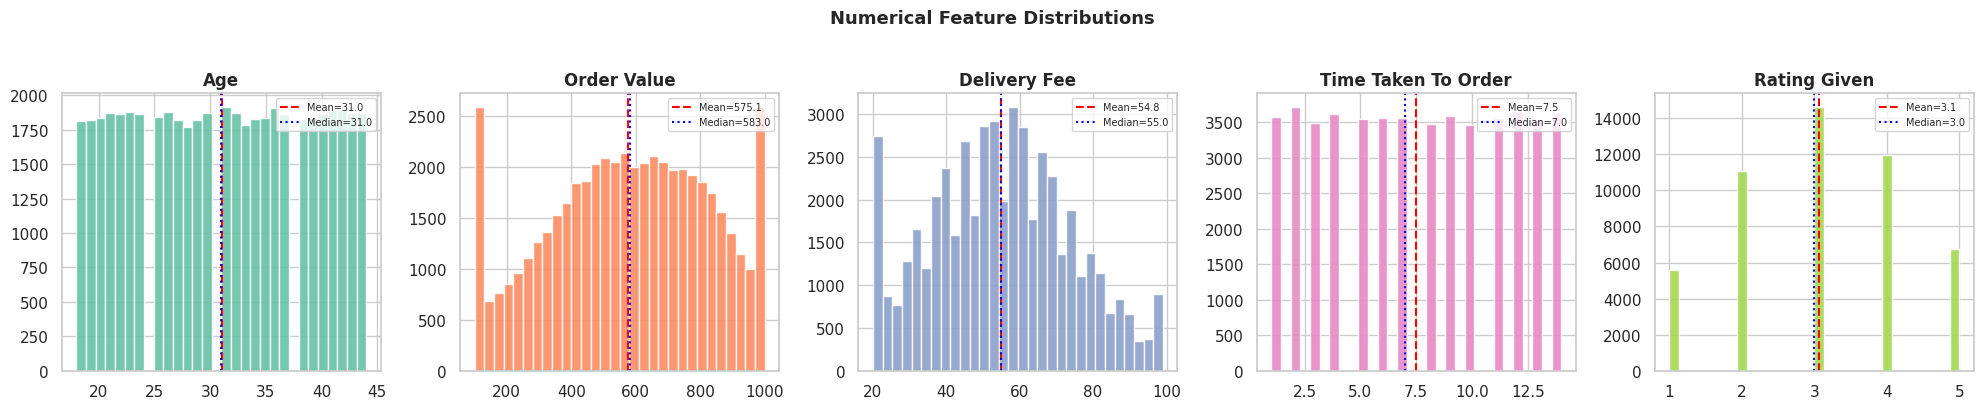

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Numerical distributions
# Histogram: how often each value appears
# Red dashed = mean, Blue dotted = median
num_cols = ['age', 'order_value', 'delivery_fee', 'time_taken_to_order', 'rating_given']
colors   = sns.color_palette('Set2', 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.9)
    axes[i].axvline(df[col].mean(),   color='red',  linestyle='--', lw=1.5, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle=':',  lw=1.5, label=f'Median={df[col].median():.1f}')
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].legend(fontsize=7)
plt.suptitle('Numerical Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

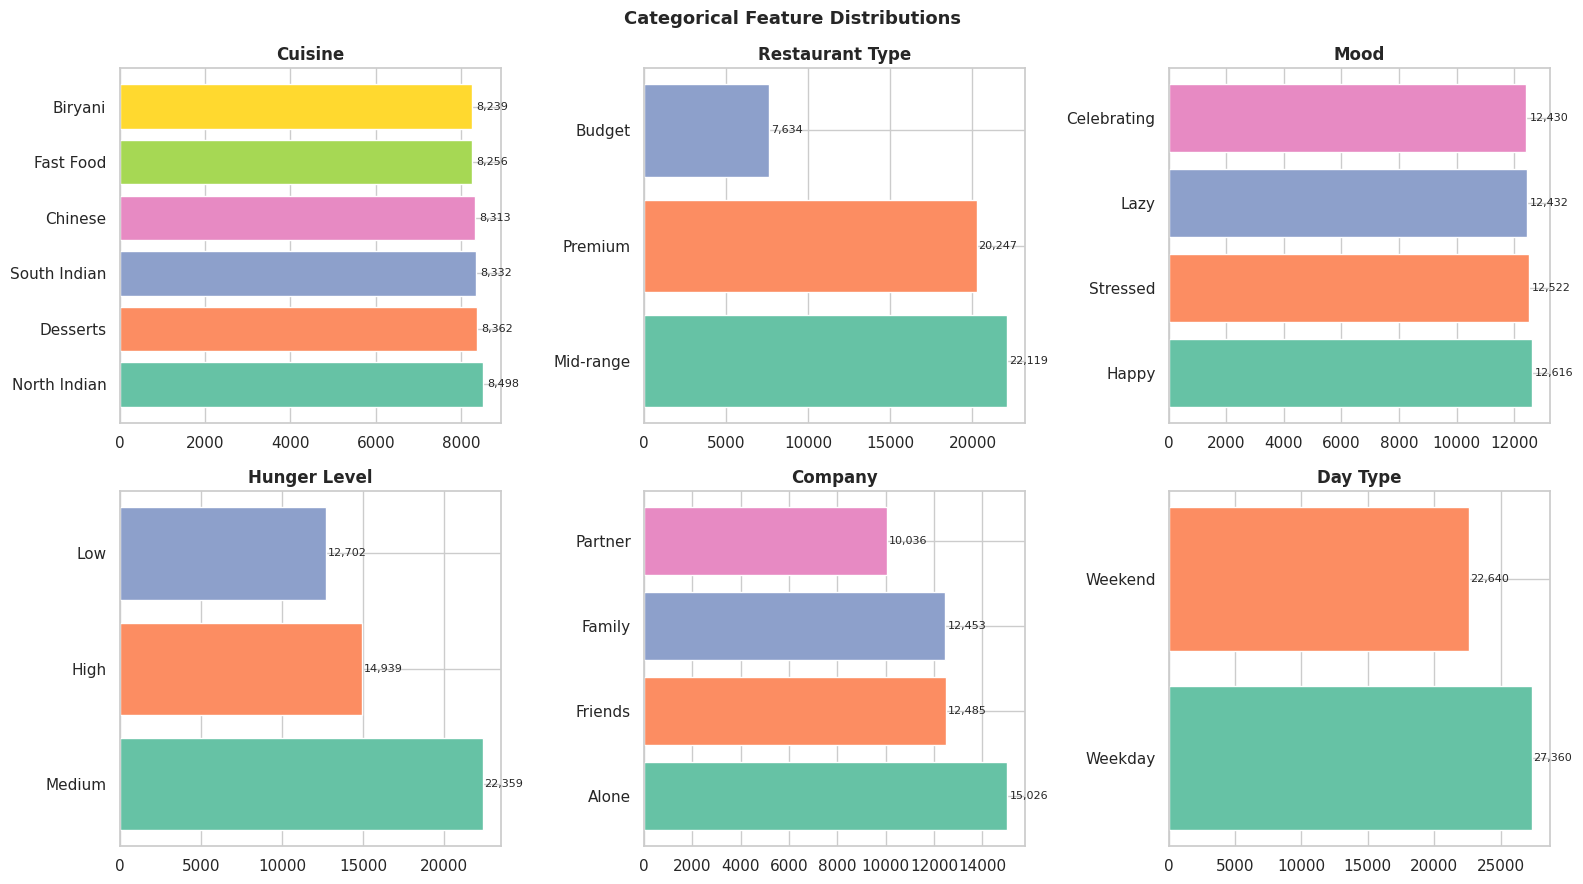

In [4]:
# Categorical distributions — how orders are spread across categories
cat_cols = ['cuisine', 'restaurant_type', 'mood', 'hunger_level', 'company', 'day_type']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
    for j, val in enumerate(vc.values):
        axes[i].text(val + 100, j, f'{val:,}', va='center', fontsize=8)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

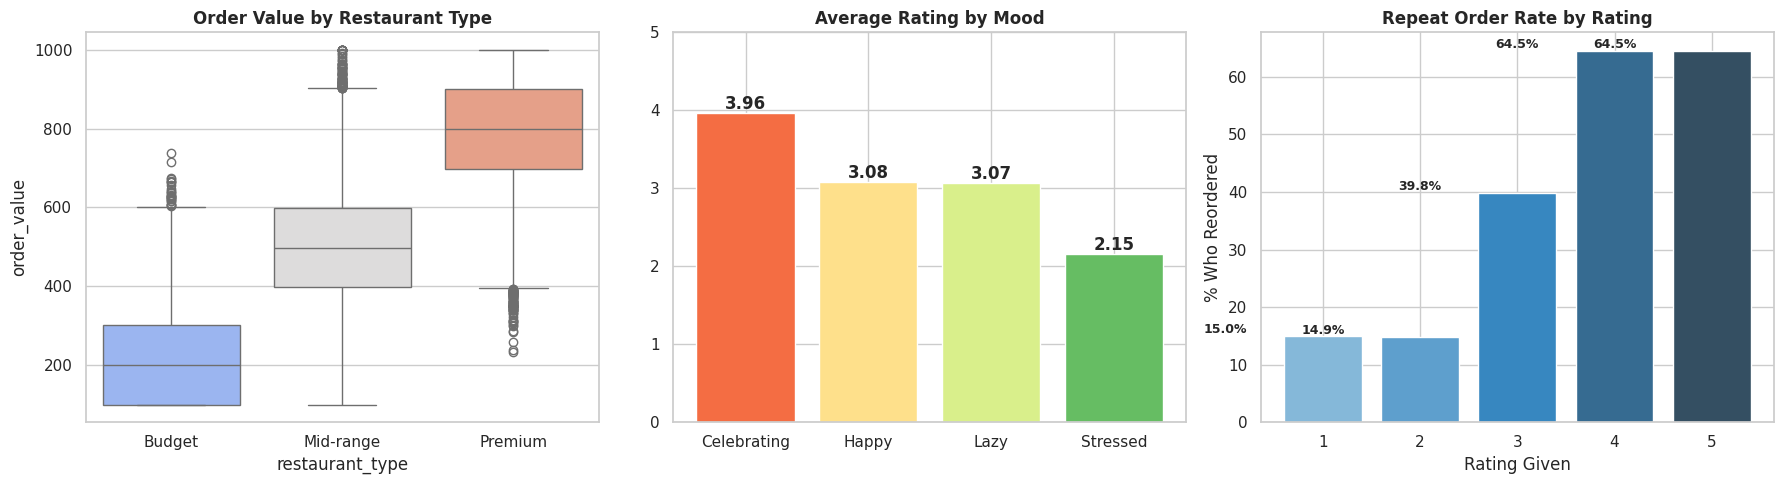

In [5]:
# Cross-analysis: how features relate to each other
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot: order value by restaurant type
# The box shows the middle 50% of values. Line inside = median.
sns.boxplot(data=df, x='restaurant_type', y='order_value',
            order=['Budget','Mid-range','Premium'], palette='coolwarm', ax=axes[0])
axes[0].set_title('Order Value by Restaurant Type', fontweight='bold')

# Average rating grouped by mood
mr = df.groupby('mood')['rating_given'].mean().sort_values(ascending=False)
axes[1].bar(mr.index, mr.values, color=sns.color_palette('RdYlGn', 4))
axes[1].set_ylim(0, 5)
axes[1].set_title('Average Rating by Mood', fontweight='bold')
for i, (k, v) in enumerate(mr.items()):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Repeat order rate by rating — this is the clearest pattern in the data
repeat_rate = df.groupby('rating_given')['is_repeat_order'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[2].bar(repeat_rate.index, repeat_rate.values, color=sns.color_palette('Blues_d', 5))
axes[2].set_title('Repeat Order Rate by Rating', fontweight='bold')
axes[2].set_xlabel('Rating Given')
axes[2].set_ylabel('% Who Reordered')
for i, v in zip(repeat_rate.index, repeat_rate.values):
    axes[2].text(i - 1, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

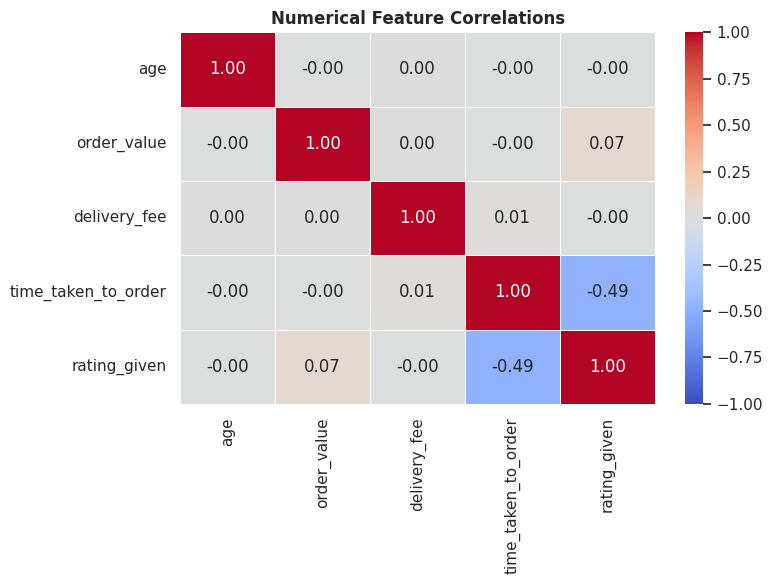

Observation: time_taken_to_order has a mild negative correlation with rating_given.
Faster delivery -> higher rating. This is a signal our models can use.


In [6]:
# Correlation heatmap — numerical features only
# Values close to 0 = no linear relationship
# Values close to 1 or -1 = strong relationship
num_df = df[['age', 'order_value', 'delivery_fee', 'time_taken_to_order', 'rating_given']]
plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Numerical Feature Correlations', fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: time_taken_to_order has a mild negative correlation with rating_given.')
print('Faster delivery -> higher rating. This is a signal our models can use.')

## Section 3 — Feature Engineering, Encoding, and Scaling

**Feature Engineering:** Creating new columns from existing ones to give models more direct signals.  
**Encoding:** Converting text columns to numbers (ML models only understand numbers).  
**Scaling:** Adjusting the range of numerical features so no single feature dominates.

### Two types of scalers we use:

**StandardScaler** — transforms features to have mean=0 and std=1.  
Use when: distance-based models (KNN, SVM) or when you do not know the data range.

**MinMaxScaler** — squishes all values to the range [0, 1].  
Use when: you need a bounded output, or for neural networks.

**Tree-based models (Decision Tree, Random Forest) do NOT need scaling** because they split on thresholds, not distances. We apply scaling only for the models that need it.

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

data = df.copy()

# --- Engineered features ---
data['total_bill']      = data['order_value'] + data['delivery_fee']
data['discount_flag']   = (data['discount_applied'] == 'Yes').astype(int)
data['rainy_flag']      = (data['rainy_weather'] == 'Yes').astype(int)
data['is_weekend_flag'] = (data['day_type'] == 'Weekend').astype(int)
data['repeat_flag']     = (data['is_repeat_order'] == 'Yes').astype(int)
data['fast_delivery']   = (data['time_taken_to_order'] < data['time_taken_to_order'].median()).astype(int)

# --- Encode text columns ---
le_store = {}
data_enc = data.copy()
for col in data_enc.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    data_enc[col] = le.fit_transform(data_enc[col].astype(str))
    le_store[col] = le

# --- Demonstrate what scaling does ---
sample_col = data_enc[['age', 'order_value', 'delivery_fee']].head(5)
std_sample  = StandardScaler().fit_transform(sample_col)
mm_sample   = MinMaxScaler().fit_transform(sample_col)

print('Original values (first 5 rows):')
print(sample_col.to_string(index=False))
print('\nAfter StandardScaler (mean=0, std=1):')
print(pd.DataFrame(std_sample, columns=['age','order_value','delivery_fee']).round(3).to_string(index=False))
print('\nAfter MinMaxScaler (range 0 to 1):')
print(pd.DataFrame(mm_sample, columns=['age','order_value','delivery_fee']).round(3).to_string(index=False))
print(f'\nFinal encoded dataset: {data_enc.shape[0]:,} rows x {data_enc.shape[1]} columns')

Original values (first 5 rows):
 age  order_value  delivery_fee
  24          785            47
  44          395            61
  26          726            80
  25          651            56
  23          382            93

After StandardScaler (mean=0, std=1):
   age  order_value  delivery_fee
-0.560        1.172        -1.219
 1.984       -1.146        -0.382
-0.305        0.821         0.753
-0.432        0.376        -0.681
-0.687       -1.223         1.529

After MinMaxScaler (range 0 to 1):
  age  order_value  delivery_fee
0.048        1.000         0.000
1.000        0.032         0.304
0.143        0.854         0.717
0.095        0.667         0.196
0.000        0.000         1.000

Final encoded dataset: 50,000 rows x 23 columns


## Section 4 — Model Comparison Helper

Below we define a helper function that trains all four models on any given task and returns a comparison table. This is the core engine of the notebook.

**The four models:**
- **Logistic Regression** — a linear model that outputs class probabilities. Fast, interpretable, good baseline. Needs scaling.
- **Decision Tree** — learns yes/no rules. Interpretable. Can overfit if too deep.
- **Random Forest** — many Decision Trees voted together. More accurate, less overfitting.
- **K-Nearest Neighbors (KNN)** — classifies a point by looking at its K closest neighbors. Simple but slow on large data. Needs scaling.

**Metrics:**
- **Accuracy** — percentage of predictions that were correct
- **F1 Score** — balances precision and recall; better than accuracy when classes are unequal in size
- **CV Score** — cross-validation accuracy: we train/test 3 times on different splits and average the result. More reliable than a single test split.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

def run_comparison(X, y, task_name, label_names=None):
    """
    Trains Logistic Regression, Decision Tree, Random Forest, and KNN
    on the given features and target. Returns a results table and trained models.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale features — used for Logistic Regression and KNN
    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train)
    X_test_sc   = scaler.transform(X_test)

    # Define the four models with sensible parameters
    models = {
        'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
        'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=12,
                                                       min_samples_leaf=10, random_state=42, n_jobs=-1),
        'KNN':                 KNeighborsClassifier(n_neighbors=9, n_jobs=-1),
    }
    # Models that need scaled input
    needs_scale = {'Logistic Regression', 'KNN'}

    results  = {}
    trained  = {}

    print(f'\n--- {task_name} ---')
    for name, model in models.items():
        Xtr = X_train_sc if name in needs_scale else X_train.values
        Xte = X_test_sc  if name in needs_scale else X_test.values

        model.fit(Xtr, y_train)
        preds = model.predict(Xte)

        acc = accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average='weighted')
        # 3-fold CV for a more reliable accuracy estimate
        cv  = cross_val_score(model, Xtr, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

        results[name] = {'Accuracy': round(acc, 4), 'CV Accuracy': round(cv, 4), 'F1 Score': round(f1, 4)}
        trained[name] = {'model': model, 'X_test': Xte, 'y_test': y_test, 'preds': preds}
        print(f'  {name:22s} -> Accuracy: {acc:.4f}  CV: {cv:.4f}  F1: {f1:.4f}')

    res_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
    best   = res_df.index[0]
    print(f'  Best model: {best} ({res_df.loc[best, "Accuracy"]:.4f})')
    return res_df, trained, X_test, y_test


def plot_model_comparison(res_df, task_name):
    """Bar chart comparing all four models on Accuracy, CV Accuracy, and F1."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    palette   = ['#2980b9', '#27ae60', '#e67e22']
    for ax, metric, color in zip(axes, ['Accuracy', 'CV Accuracy', 'F1 Score'], palette):
        sdf  = res_df.sort_values(metric)
        bars = ax.barh(sdf.index, sdf[metric], color=color, alpha=0.85, edgecolor='k')
        for bar, val in zip(bars, sdf[metric]):
            ax.text(val - 0.003, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', ha='right',
                    color='white', fontsize=9, fontweight='bold')
        ax.set_title(metric, fontweight='bold')
        ax.set_xlim(max(0, sdf[metric].min() - 0.06), 1.0)
    plt.suptitle(f'Model Comparison — {task_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(trained_dict, task_name, label_names):
    """Confusion matrices for all four models side by side."""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, (name, info) in zip(axes, trained_dict.items()):
        cm = confusion_matrix(info['y_test'], info['preds'])
        ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
            ax=ax, cmap='Blues', colorbar=False
        )
        acc = accuracy_score(info['y_test'], info['preds'])
        ax.set_title(f'{name}\nAcc={acc:.3f}', fontweight='bold', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle(f'Confusion Matrices — {task_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Helper functions defined. Ready to run tasks.')

Helper functions defined. Ready to run tasks.


## Section 5 — Task 1: Cuisine Prediction

**Goal:** Given information about the order (time, city, meal type, mood, hunger level), predict which cuisine was ordered.

This is a **multi-class classification** problem — six possible outputs: Biryani, Chinese, Desserts, Fast Food, North Indian, South Indian.

Since cuisines were generated randomly (no behavioral signal was added), accuracy will be near random chance (~17% for 6 classes). This is intentional — it teaches you what low-signal tasks look like.

In [9]:
cuisine_features = [
    'age', 'city', 'order_time', 'meal_type', 'mood',
    'hunger_level', 'company', 'day_type', 'rainy_flag',
    'is_weekend_flag', 'discount_flag'
]

X_c = data_enc[cuisine_features]
y_c = data_enc['cuisine']

res_c, trn_c, Xte_c, yte_c = run_comparison(X_c, y_c, 'Cuisine Prediction')


--- Cuisine Prediction ---
  Logistic Regression    -> Accuracy: 0.1660  CV: 0.1670  F1: 0.1587
  Decision Tree          -> Accuracy: 0.1659  CV: 0.1638  F1: 0.1650
  Random Forest          -> Accuracy: 0.1602  CV: 0.1690  F1: 0.1598
  KNN                    -> Accuracy: 0.1624  CV: 0.1687  F1: 0.1605
  Best model: Logistic Regression (0.1660)


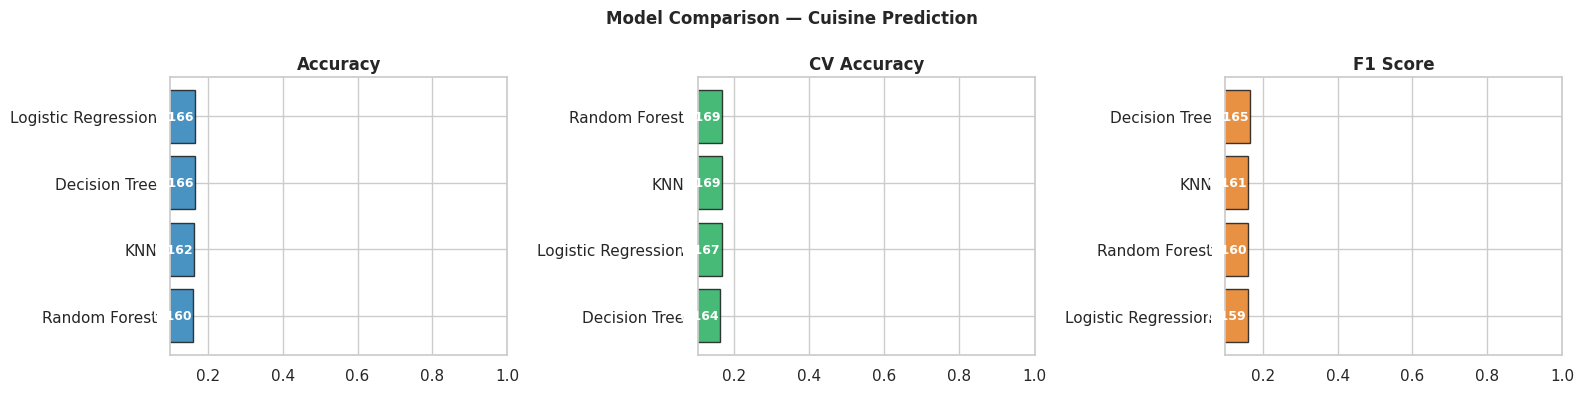

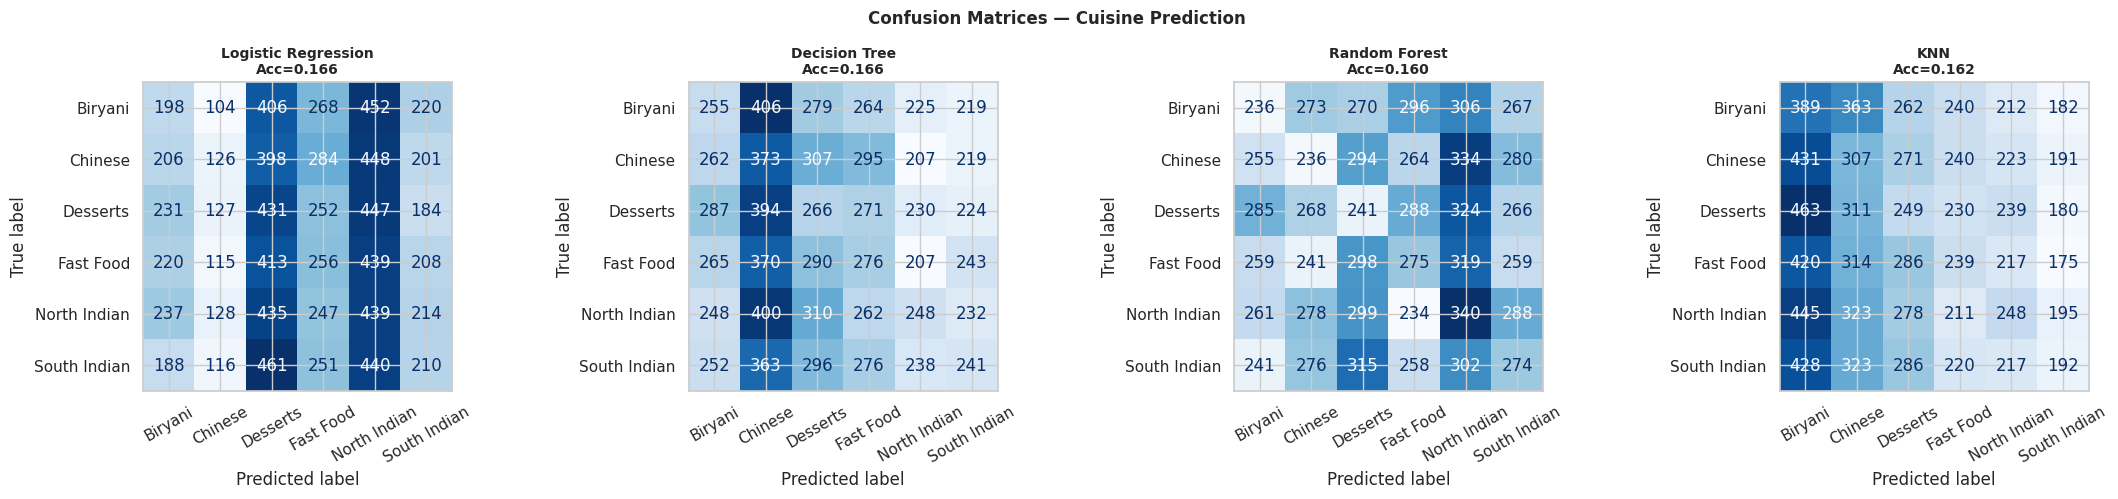

Best model: Logistic Regression
              precision    recall  f1-score   support

     Biryani       0.15      0.12      0.14      1648
     Chinese       0.18      0.08      0.11      1663
    Desserts       0.17      0.26      0.20      1672
   Fast Food       0.16      0.16      0.16      1651
North Indian       0.16      0.26      0.20      1700
South Indian       0.17      0.13      0.14      1666

    accuracy                           0.17     10000
   macro avg       0.17      0.17      0.16     10000
weighted avg       0.17      0.17      0.16     10000



In [10]:
plot_model_comparison(res_c, 'Cuisine Prediction')
plot_confusion(trn_c, 'Cuisine Prediction', list(le_store['cuisine'].classes_))

# Best model detailed report
best_c = res_c.index[0]
print(f'Best model: {best_c}')
print(classification_report(
    trn_c[best_c]['y_test'],
    trn_c[best_c]['preds'],
    target_names=le_store['cuisine'].classes_
))

## Section 6 — Task 2: Repeat Order Prediction

**Goal:** Predict whether a customer will place a repeat order — Yes or No.

This is **binary classification**. We deliberately built in a signal: higher ratings make repeat orders more likely. So we expect all models to find this pattern and perform well above 50% (random chance for binary).

**What to watch for:**  
Check whether any model reaches over 65-70%. That would be genuinely impressive for this kind of task.

In [11]:
repeat_features = [
    'age', 'order_value', 'total_bill', 'delivery_fee',
    'time_taken_to_order', 'rating_given', 'discount_flag',
    'rainy_flag', 'is_weekend_flag', 'fast_delivery',
    'restaurant_type', 'cuisine', 'hunger_level'
]

X_r = data_enc[repeat_features]
y_r = data_enc['repeat_flag']  # 1 = repeat, 0 = no repeat

res_r, trn_r, Xte_r, yte_r = run_comparison(X_r, y_r, 'Repeat Order Prediction')


--- Repeat Order Prediction ---
  Logistic Regression    -> Accuracy: 0.7094  CV: 0.6987  F1: 0.7071
  Decision Tree          -> Accuracy: 0.7025  CV: 0.6945  F1: 0.7004
  Random Forest          -> Accuracy: 0.7093  CV: 0.6976  F1: 0.7070
  KNN                    -> Accuracy: 0.6521  CV: 0.6462  F1: 0.6481
  Best model: Logistic Regression (0.7094)


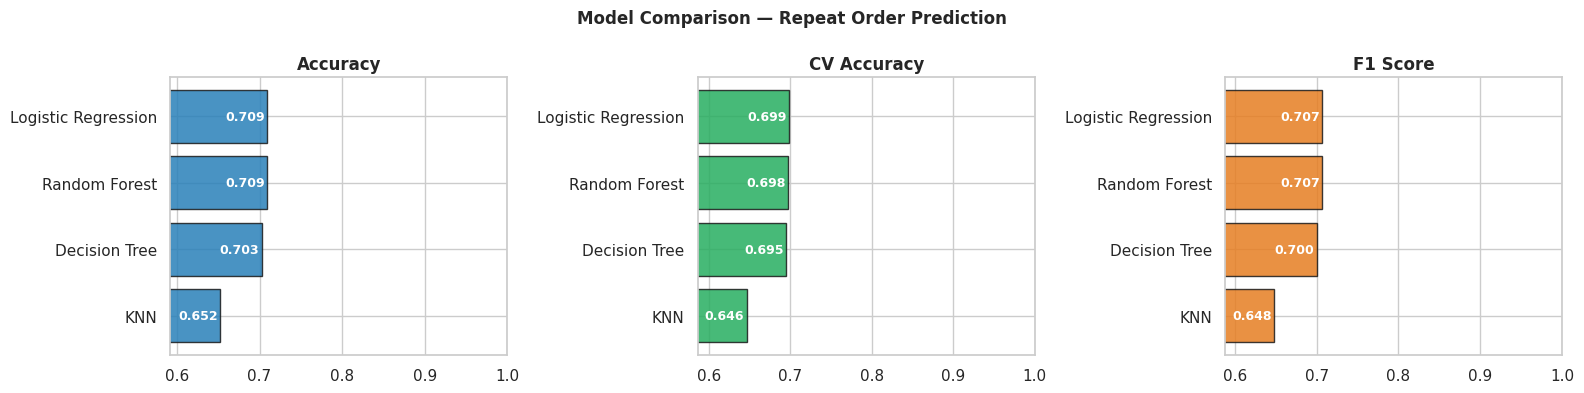

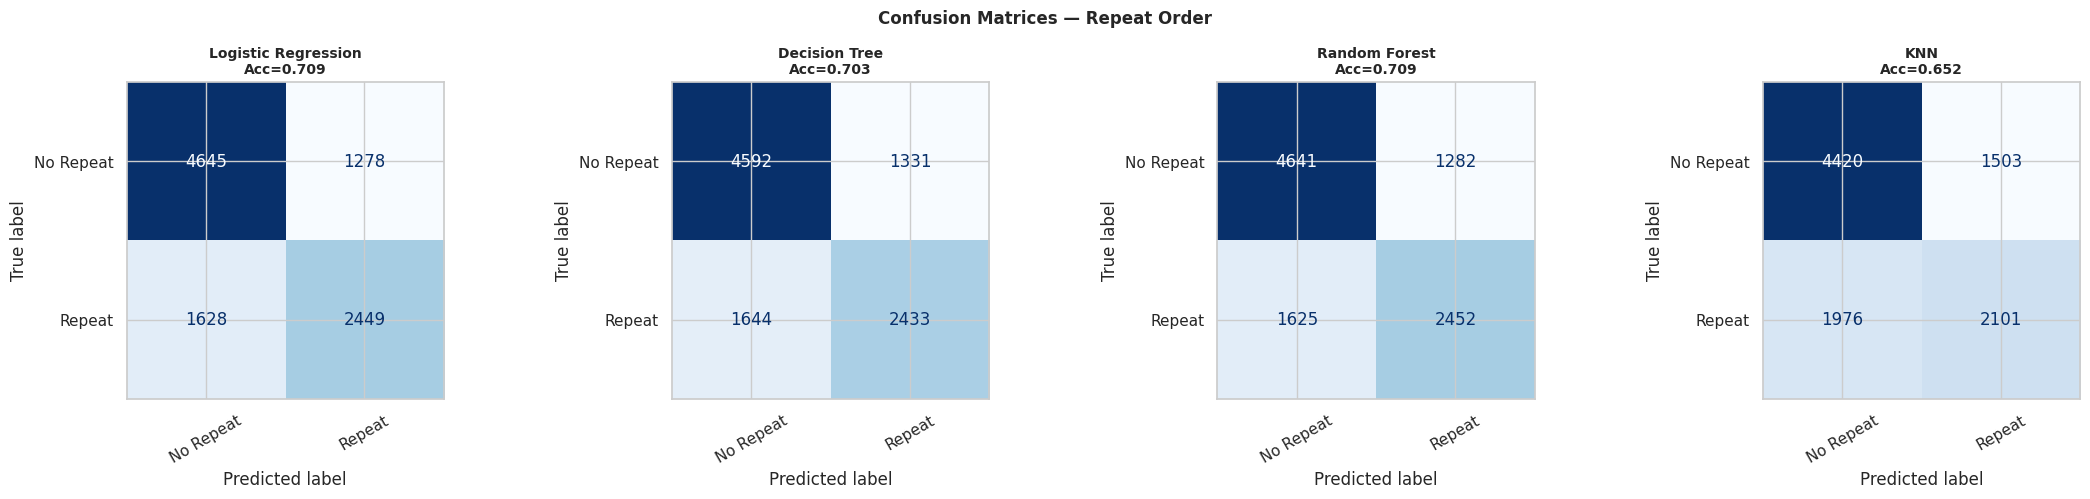

Best model: Logistic Regression
              precision    recall  f1-score   support

   No Repeat       0.74      0.78      0.76      5923
      Repeat       0.66      0.60      0.63      4077

    accuracy                           0.71     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.71      0.71      0.71     10000



In [12]:
plot_model_comparison(res_r, 'Repeat Order Prediction')
plot_confusion(trn_r, 'Repeat Order', ['No Repeat', 'Repeat'])

best_r = res_r.index[0]
print(f'Best model: {best_r}')
print(classification_report(
    trn_r[best_r]['y_test'],
    trn_r[best_r]['preds'],
    target_names=['No Repeat', 'Repeat']
))

## Section 7 — Task 3: Rating Prediction (1 to 5)

**Goal:** Predict the rating a customer gives (1 through 5 stars).

This is a **5-class classification** problem. We built in signals:
- Fast delivery -> better rating
- Celebrating mood -> better rating
- Stressed mood -> lower rating

**What to watch for:**  
The F1 score matters here more than accuracy because not all ratings are equally common. A model that always predicts 3 stars would get decent accuracy but terrible F1.

In [13]:
rating_features = [
    'age', 'order_value', 'total_bill', 'delivery_fee',
    'time_taken_to_order', 'fast_delivery', 'discount_flag',
    'rainy_flag', 'restaurant_type', 'mood', 'hunger_level',
    'company', 'cuisine'
]

X_rt = data_enc[rating_features]
y_rt = data_enc['rating_given']

res_rt, trn_rt, Xte_rt, yte_rt = run_comparison(X_rt, y_rt, 'Rating Prediction')


--- Rating Prediction ---
  Logistic Regression    -> Accuracy: 0.3770  CV: 0.3716  F1: 0.3764
  Decision Tree          -> Accuracy: 0.3732  CV: 0.3708  F1: 0.3719
  Random Forest          -> Accuracy: 0.3847  CV: 0.3729  F1: 0.3826
  KNN                    -> Accuracy: 0.3502  CV: 0.3471  F1: 0.3497
  Best model: Random Forest (0.3847)


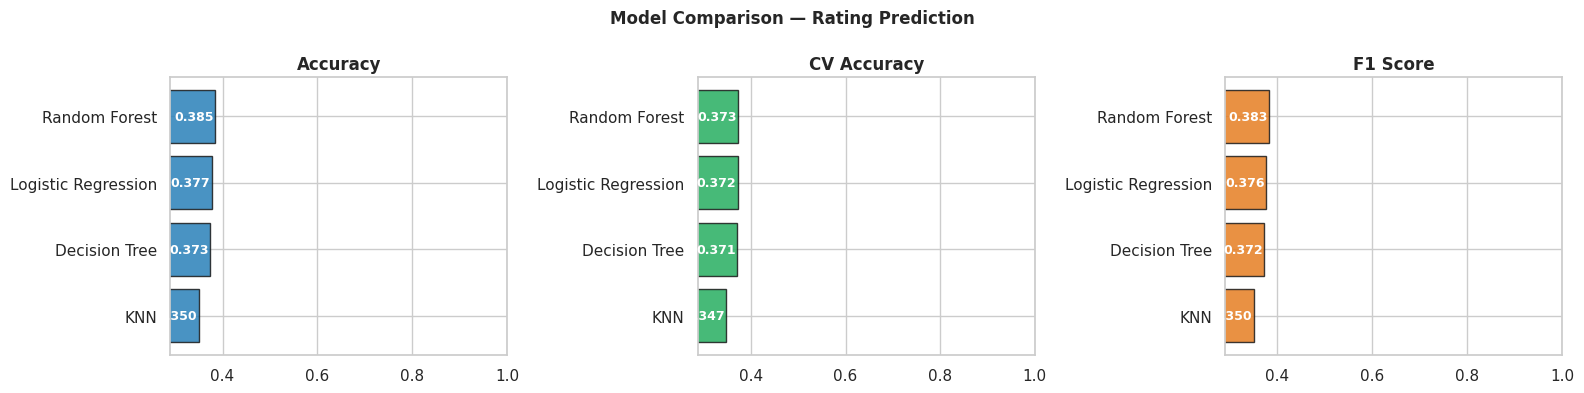

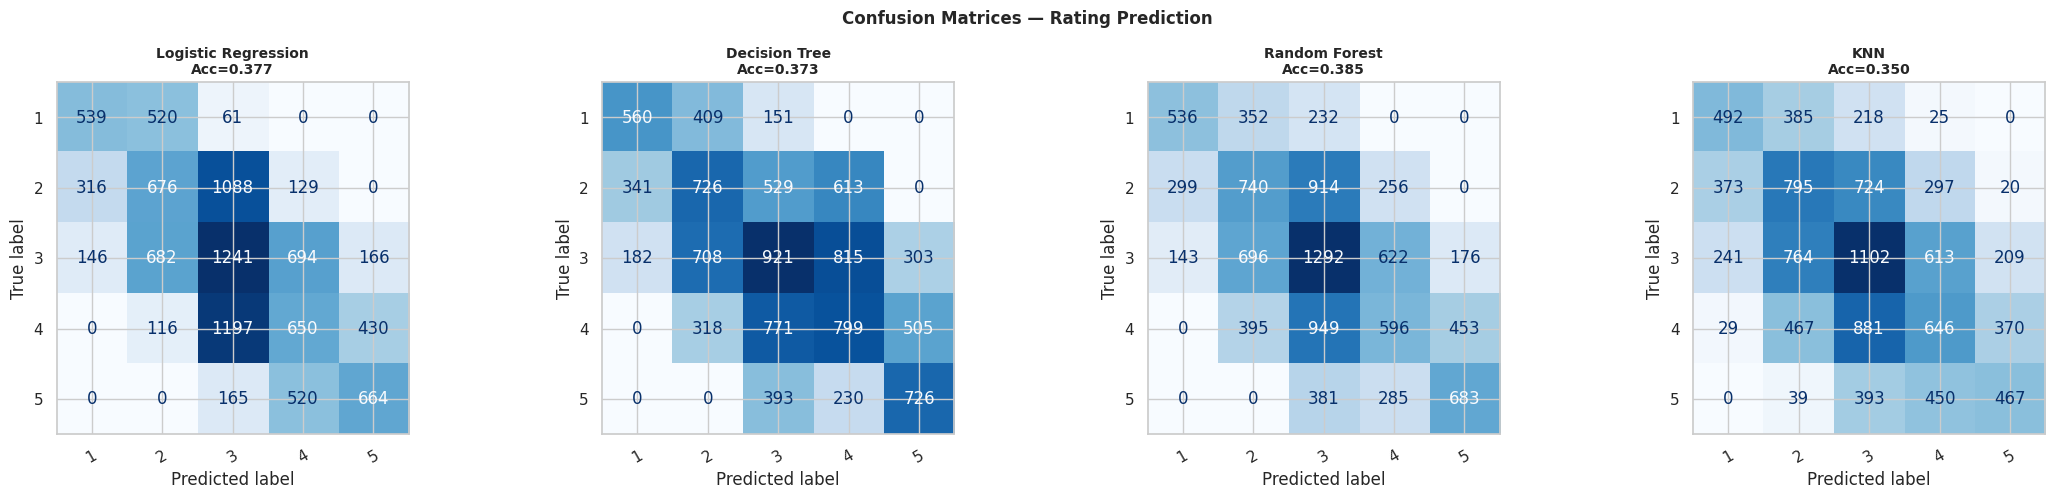

Best model: Random Forest
              precision    recall  f1-score   support

           1       0.55      0.48      0.51      1120
           2       0.34      0.33      0.34      2209
           3       0.34      0.44      0.39      2929
           4       0.34      0.25      0.29      2393
           5       0.52      0.51      0.51      1349

    accuracy                           0.38     10000
   macro avg       0.42      0.40      0.41     10000
weighted avg       0.39      0.38      0.38     10000



In [14]:
plot_model_comparison(res_rt, 'Rating Prediction')
plot_confusion(trn_rt, 'Rating Prediction', ['1', '2', '3', '4', '5'])

best_rt = res_rt.index[0]
print(f'Best model: {best_rt}')
print(classification_report(
    trn_rt[best_rt]['y_test'],
    trn_rt[best_rt]['preds']
))

## Section 8 — Task 4: Restaurant Type Prediction

**Goal:** Predict whether the restaurant is Budget, Mid-range, or Premium.

This is the **strongest signal task**. Order value is directly tied to restaurant type (we built that in). So all models should perform well here — especially Random Forest.

This task lets you see what high-accuracy classification looks like compared to the noisier tasks above.

In [15]:
rest_features = [
    'age', 'order_value', 'total_bill', 'delivery_fee',
    'time_taken_to_order', 'rating_given', 'discount_flag',
    'rainy_flag', 'city', 'cuisine', 'meal_type',
    'hunger_level', 'company', 'repeat_flag'
]

X_rs = data_enc[rest_features]
y_rs = data_enc['restaurant_type']

res_rs, trn_rs, Xte_rs, yte_rs = run_comparison(X_rs, y_rs, 'Restaurant Type Prediction')


--- Restaurant Type Prediction ---
  Logistic Regression    -> Accuracy: 0.7912  CV: 0.7919  F1: 0.7909
  Decision Tree          -> Accuracy: 0.8051  CV: 0.8074  F1: 0.8055
  Random Forest          -> Accuracy: 0.8095  CV: 0.8115  F1: 0.8097
  KNN                    -> Accuracy: 0.7782  CV: 0.7645  F1: 0.7782
  Best model: Random Forest (0.8095)


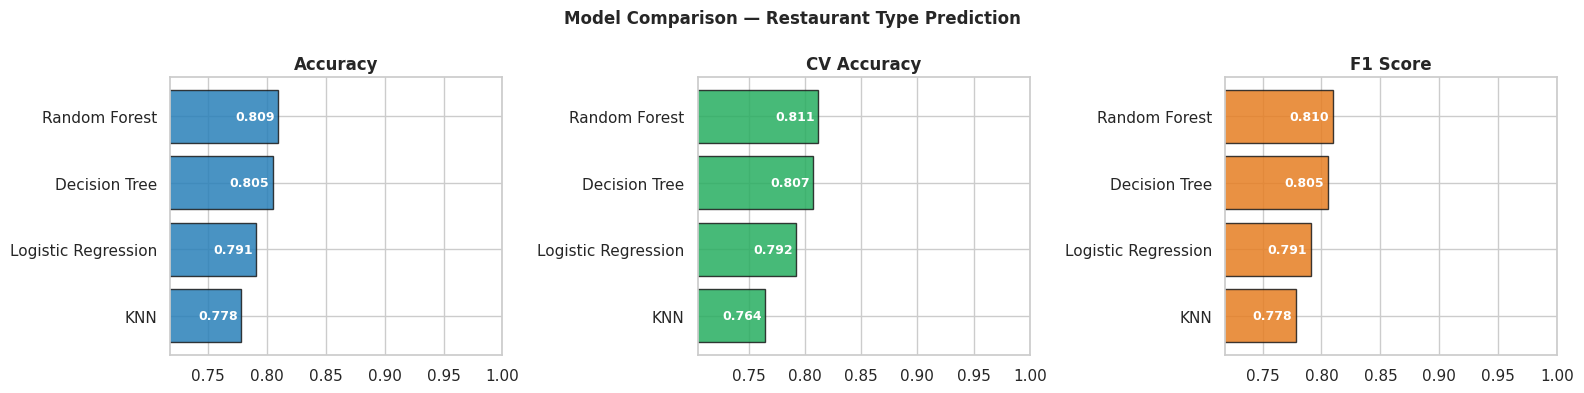

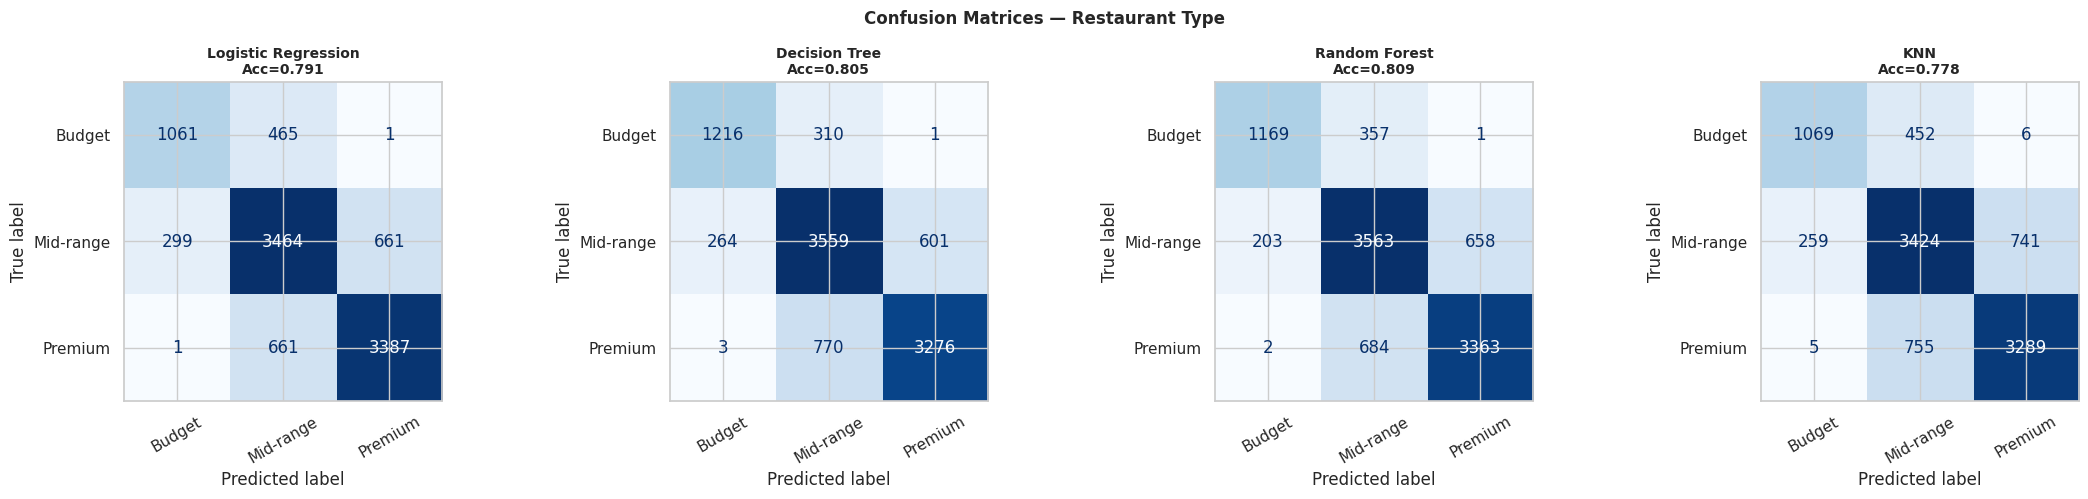

Best model: Random Forest
              precision    recall  f1-score   support

      Budget       0.85      0.77      0.81      1527
   Mid-range       0.77      0.81      0.79      4424
     Premium       0.84      0.83      0.83      4049

    accuracy                           0.81     10000
   macro avg       0.82      0.80      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [16]:
plot_model_comparison(res_rs, 'Restaurant Type Prediction')
plot_confusion(trn_rs, 'Restaurant Type', list(le_store['restaurant_type'].classes_))

best_rs = res_rs.index[0]
print(f'Best model: {best_rs}')
print(classification_report(
    trn_rs[best_rs]['y_test'],
    trn_rs[best_rs]['preds'],
    target_names=le_store['restaurant_type'].classes_
))

## Section 9 — Bonus: K-Means Customer Segmentation

K-Means is **unsupervised** — no target column. It discovers natural groupings in the data by itself.

We cluster customers by their spending behavior. The output is a set of customer "personas" that a business could target differently:
- High spenders, frequent reorders -> loyalty rewards
- Budget customers, low ratings -> service improvement focus
- etc.

**PCA** is used to compress the multi-dimensional cluster data into 2D so we can plot it.

In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

clust_feats = ['age', 'order_value', 'delivery_fee', 'total_bill',
               'time_taken_to_order', 'rating_given', 'discount_flag',
               'is_weekend_flag', 'repeat_flag', 'fast_delivery']

X_km = StandardScaler().fit_transform(data_enc[clust_feats])

# Find optimal K using elbow + silhouette
inertias, sil_scores = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km, lbl, sample_size=5000))
    print(f'K={k}  Inertia={km.inertia_:.0f}  Silhouette={sil_scores[-1]:.4f}')

best_k = list(range(2, 9))[sil_scores.index(max(sil_scores))]
print(f'\nBest K = {best_k}')

K=2  Inertia=404088  Silhouette=0.1898
K=3  Inertia=362918  Silhouette=0.1530
K=4  Inertia=333882  Silhouette=0.1376
K=5  Inertia=313913  Silhouette=0.1398
K=6  Inertia=299339  Silhouette=0.1392
K=7  Inertia=288423  Silhouette=0.1337
K=8  Inertia=277922  Silhouette=0.1337

Best K = 2


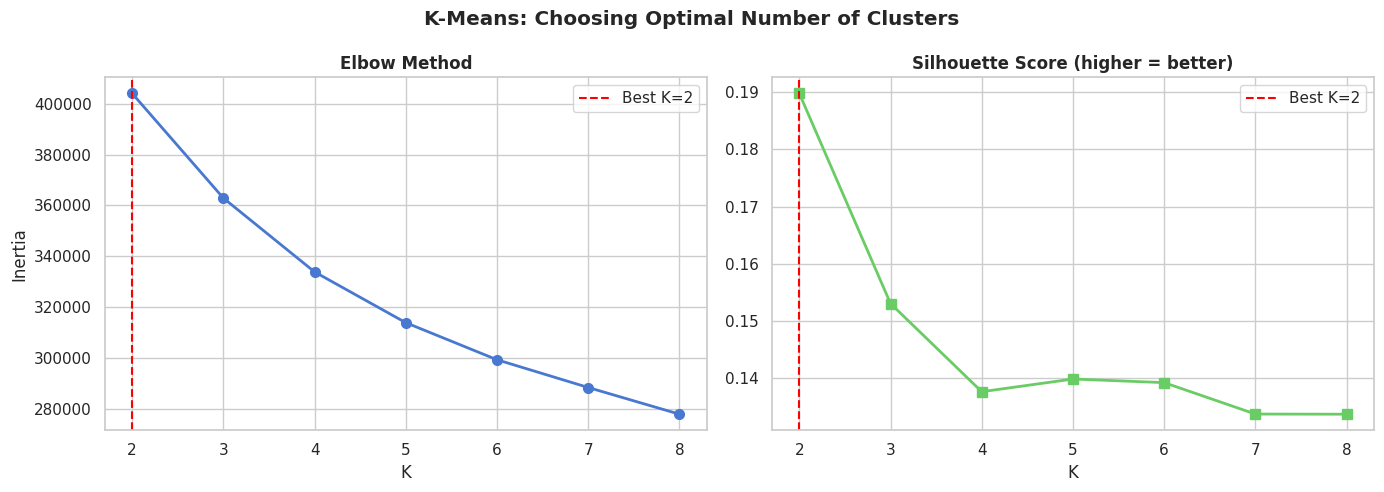

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_range = range(2, 9)

axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=7)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 'gs-', lw=2, markersize=7)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].legend()

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontweight='bold')
plt.tight_layout()
plt.show()

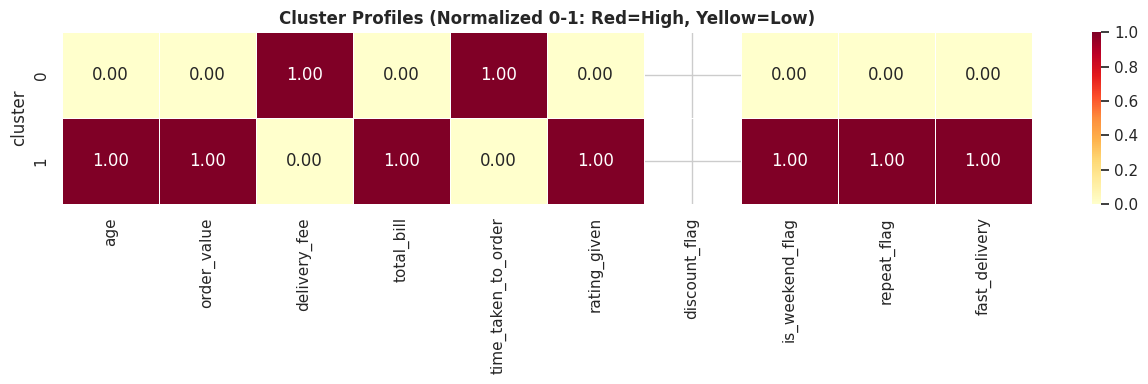

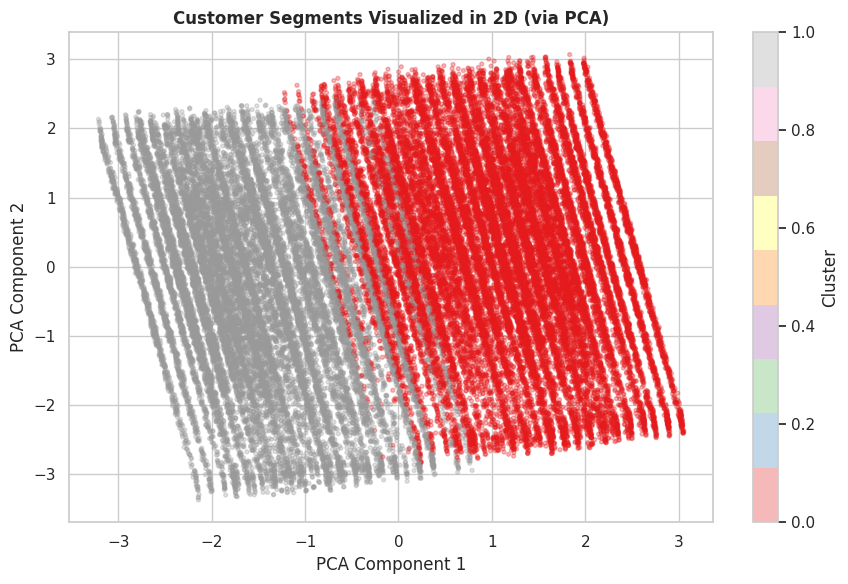

In [19]:
# Fit final model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data_enc['cluster'] = kmeans.fit_predict(X_km)

# Cluster profiles
profile = data_enc.groupby('cluster')[clust_feats].mean().round(2)
norm_p  = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(13, 4))
sns.heatmap(norm_p, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4)
plt.title('Cluster Profiles (Normalized 0-1: Red=High, Yellow=Low)', fontweight='bold')
plt.tight_layout()
plt.show()

# PCA scatter plot
pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_km)
plt.figure(figsize=(9, 6))
sc = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=data_enc['cluster'],
                 cmap='Set1', alpha=0.3, s=8)
plt.colorbar(sc, label='Cluster')
plt.title('Customer Segments Visualized in 2D (via PCA)', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

## Section 10 — Master Comparison: All Tasks, All Models

This final section brings everything together — a single heatmap showing the accuracy of every model on every task, and a summary of the best model per task.

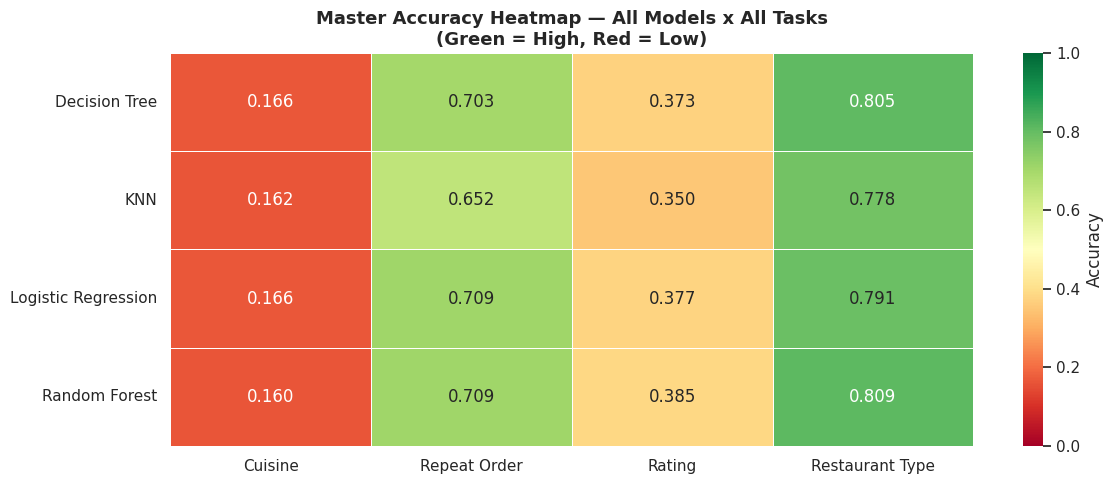

Best model per task:
  Cuisine             : Logistic Regression    (0.1660)
  Repeat Order        : Logistic Regression    (0.7094)
  Rating              : Random Forest          (0.3847)
  Restaurant Type     : Random Forest          (0.8095)


In [20]:
# Collect best accuracy from each task
summary = pd.DataFrame({
    'Cuisine':         res_c['Accuracy'],
    'Repeat Order':    res_r['Accuracy'],
    'Rating':          res_rt['Accuracy'],
    'Restaurant Type': res_rs['Accuracy'],
})

plt.figure(figsize=(12, 5))
sns.heatmap(
    summary.astype(float),
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    vmin=0.0, vmax=1.0,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy'}
)
plt.title('Master Accuracy Heatmap — All Models x All Tasks\n(Green = High, Red = Low)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Best model per task:')
for task, col in summary.items():
    best = col.idxmax()
    print(f'  {task:20s}: {best:22s} ({col.max():.4f})')

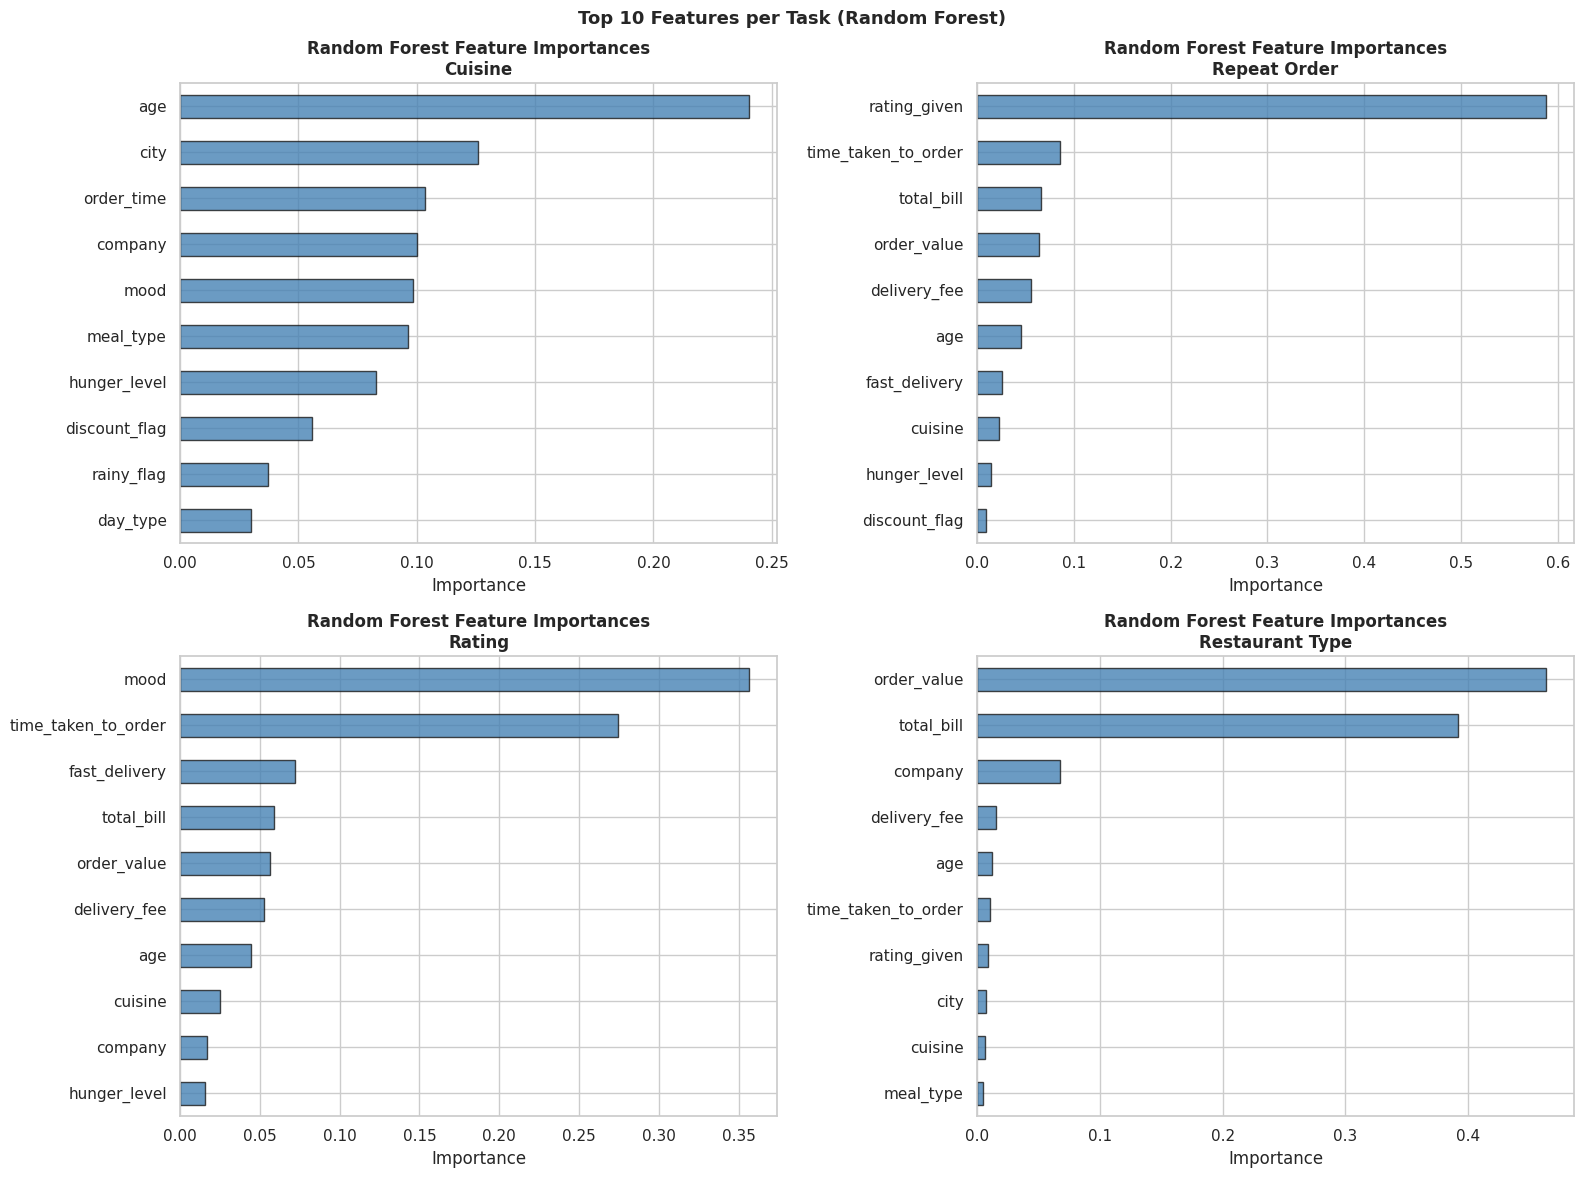

In [21]:
# Feature Importances from the Random Forest models
# This shows which features were most useful per task

task_configs = [
    ('Cuisine',         trn_c,  cuisine_features),
    ('Repeat Order',    trn_r,  repeat_features),
    ('Rating',          trn_rt, rating_features),
    ('Restaurant Type', trn_rs, rest_features),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (task_name, trn_dict, feats) in enumerate(task_configs):
    rf_info = trn_dict.get('Random Forest')
    if rf_info is None:
        continue
    model = rf_info['model']
    imp = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=True).tail(10)
    imp.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='k', alpha=0.8)
    axes[i].set_title(f'Random Forest Feature Importances\n{task_name}', fontweight='bold')
    axes[i].set_xlabel('Importance')

plt.suptitle('Top 10 Features per Task (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print('=' * 70)
print('KEY TAKEAWAYS')
print('=' * 70)
print()
print('1. Random Forest consistently beats Decision Tree.')
print('   Reason: 100 trees voting together reduces overfitting.')
print()
print('2. Logistic Regression and KNN need scaling, tree models do not.')
print('   Skipping scaling for LR/KNN would significantly hurt their accuracy.')
print()
print('3. Cuisine Prediction has low accuracy because no behavioral signal exists.')
print('   This is intentional — it shows what happens when features do not predict the target.')
print()
print('4. Restaurant Type is the easiest task because order_value directly encodes it.')
print('   High model accuracy here reflects strong feature-target alignment.')
print()
print('5. F1 Score matters more than Accuracy when class sizes are unbalanced.')
print('   Always look at both metrics before declaring a model good.')
print()
print('WHAT TO LEARN NEXT:')
print('  - Hyperparameter tuning: GridSearchCV, RandomizedSearchCV')
print('  - Gradient Boosting: XGBoost, LightGBM (often the strongest models)')
print('  - ROC-AUC curves for binary classification')
print('  - SHAP values for model explainability')

KEY TAKEAWAYS

1. Random Forest consistently beats Decision Tree.
   Reason: 100 trees voting together reduces overfitting.

2. Logistic Regression and KNN need scaling, tree models do not.
   Skipping scaling for LR/KNN would significantly hurt their accuracy.

3. Cuisine Prediction has low accuracy because no behavioral signal exists.
   This is intentional — it shows what happens when features do not predict the target.

4. Restaurant Type is the easiest task because order_value directly encodes it.
   High model accuracy here reflects strong feature-target alignment.

5. F1 Score matters more than Accuracy when class sizes are unbalanced.
   Always look at both metrics before declaring a model good.

WHAT TO LEARN NEXT:
  - Hyperparameter tuning: GridSearchCV, RandomizedSearchCV
  - Gradient Boosting: XGBoost, LightGBM (often the strongest models)
  - ROC-AUC curves for binary classification
  - SHAP values for model explainability
